# 05 Review Pack

This notebook is the final presentation layer: summarize the evaluation population, focus on flagged bonds, and explain why each case would or would not need analyst review.

The purpose of this step is to turn the pricing output into something operational. A reviewer should be able to look at a short list of names, understand why they were escalated, and decide where deeper investigation is worth the time.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from IPython.display import Image, display

from src.review_pack import build_flagged_summary, build_summary_metrics, load_evaluation_table

In [3]:
evaluation_table = load_evaluation_table(PROJECT_ROOT / "outputs" / "daily_eval_table.csv")
summary = build_summary_metrics(evaluation_table)
summary

,evaluation_date,bond_count,review_count,high_review_count,avg_abs_spread_residual_bps,avg_abs_price_residual,max_abs_spread_residual_bps,max_abs_price_residual
0,1991-03-14,8,6,3,19.701344,1.174484,50.528346,3.860197


In [4]:
flagged = build_flagged_summary(evaluation_table)
flagged

,bond_id,issuer,dirty_price,fair_model_dirty_price,price_residual,spread_to_curve,fair_spread,spread_residual_bps,comp_count,review_flag,review_reason
1,GE_1998_725,GE,102.123287,103.046896,-0.923608,-0.005841,-0.007367,15.259302,3,Review,moderate spread residual; moderate price residual
3,IBM_1996_700,IBM,104.660663,104.042091,0.618572,-0.009468,-0.008165,-13.037852,3,Review,moderate spread residual; moderate price residual
6,XOM_1997_710,XOM,100.759558,100.078558,0.681000,-0.006754,-0.005379,-13.751412,3,Review,moderate spread residual; moderate price residual
7,XOM_2001_760,XOM,101.500549,105.360746,-3.860197,-0.001546,-0.006599,50.528346,3,High Review,large spread residual; large price residual
5,JNJ_2000_740,JNJ,102.352597,104.446233,-2.093636,-0.005196,-0.008225,30.285345,3,High Review,large spread residual; large price residual
4,JNJ_1995_675,JNJ,101.434503,100.397115,1.037388,-0.008968,-0.006308,-26.603716,3,High Review,large spread residual; large price residual


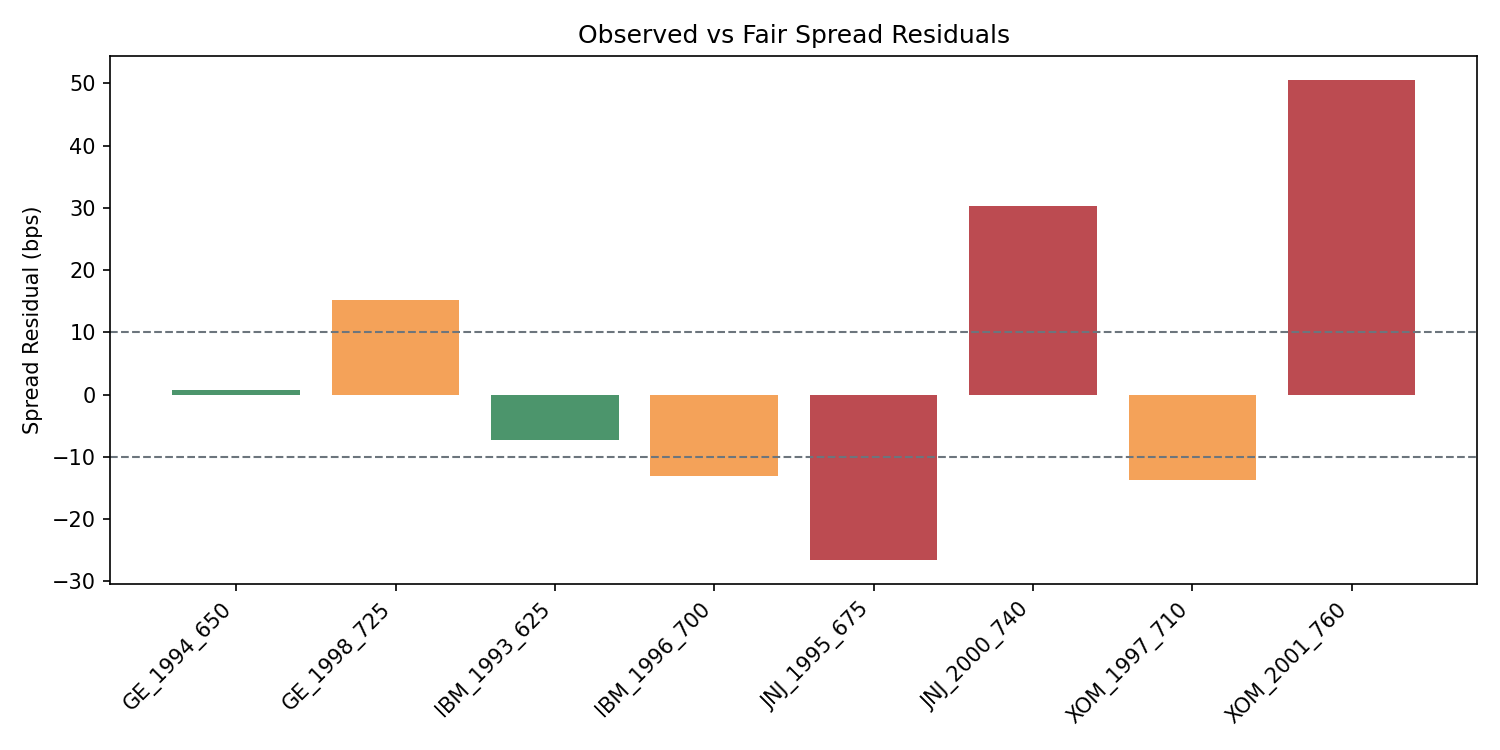

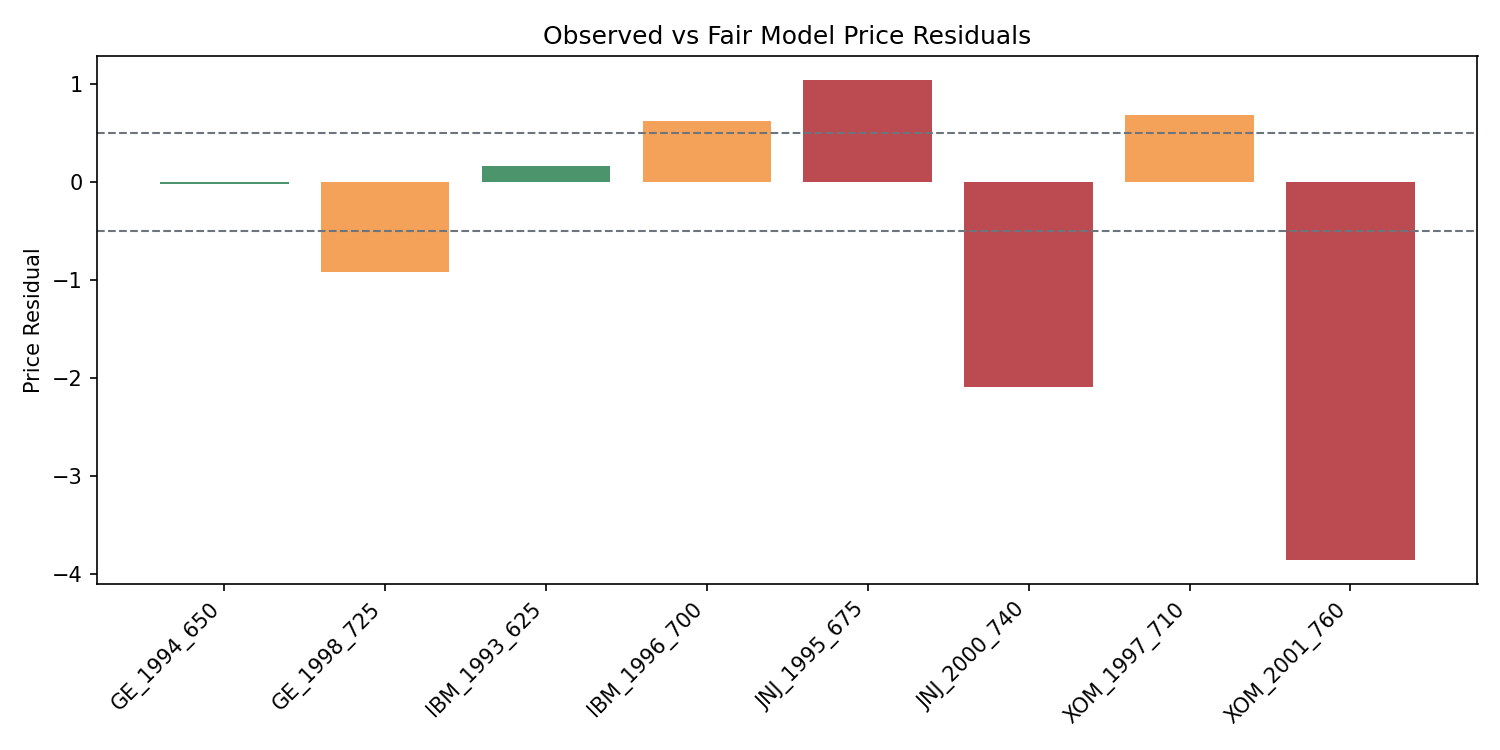

In [5]:
chart_dir = PROJECT_ROOT / "outputs" / "charts"
display(Image(filename=str(chart_dir / "spread_residuals.png")))
display(Image(filename=str(chart_dir / "price_residuals.png")))

In the current sample, the flagged population is driven by synthetic bond inputs rather than live market data. That is still useful because it demonstrates the workflow clearly: the model produces a fair-value view, compares it with observed levels, and routes the largest gaps into a compact exception list.